# PROYECTO INTEGRADOR: Fuga de Clientes con Segmentación de Valor (Customer Churn)
## Cuaderno 02: Preparación Reproducible, Baselines y Modelos Preliminares
**Curso:** Data Mining Tools (CC209) — UPC  
**Fase:** Trabajo Parcial (TP1) — Semana 7  
**Docente:** Carlos Fernando Montoya Cubas  

---

### Objetivos del Cuaderno
1. **Garantizar Cero Data Leakage:** Implementar partición estratificada antes de cualquier transformación y ajustar el `ColumnTransformer` exclusivamente sobre los datos de entrenamiento.
2. **Definir Baselines de Referencia:** Evaluar un clasificador trivial (`DummyClassifier`) y un clasificador heurístico de reglas de negocio para contestar con rigor: *¿El Machine Learning aporta valor sobre soluciones simples?*
3. **Entrenar y Comparar Modelos Preliminares:** Comparar una solución lineal interpretable (`LogisticRegression`) versus una basada en ensambles de árboles (`RandomForestClassifier`) con ponderación equilibrada de clases.
4. **Evaluación de Negocio y Matriz de Costo:** Analizar la matriz de confusión traduciendo Falsos Negativos y Falsos Positivos a impacto económico real (\$ USD).
5. **Estado Actual y Plan hacia el Trabajo Final (TF1):** Documentar las limitaciones actuales y trazar la hoja de ruta para la optimización con Optuna, tracking con MLflow, segmentación con K-Means, explicabilidad con SHAP y despliegue en Streamlit.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Entorno y módulos cargados exitosamente.")

Entorno y módulos cargados exitosamente.


### 1. Carga de Datos y Estrategia de Partición Anti-Leakage (Rúbrica Criterio 4)

**Principio de Prevención de Data Leakage:**
Cualquier cálculo de estadísticas (medias, medianas, modas, desviaciones estándar o categorías de One-Hot Encoding) sobre el conjunto de prueba contamina el proceso de validación. Por ello, la división se ejecuta de forma inmediata tras cargar los datos brutos.

In [2]:
# Carga de datos
data_path = Path('../data/raw/telco_customer_churn.csv')
if not data_path.exists():
    data_path = Path('data/raw/telco_customer_churn.csv')

df_raw = pd.read_csv(data_path)

# Tratamiento inicial de anomalía conocida (TotalCharges con espacios para tenure=0)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

# Separación de features (X) y target (y), excluyendo el identificador customerID
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

# Split estratificado 80% Train / 20% Test con semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Dimensiones Train: {X_train.shape[0]} filas | Churn Rate: {y_train.mean():.2%}")
print(f"Dimensiones Test:  {X_test.shape[0]} filas | Churn Rate: {y_test.mean():.2%}")

Dimensiones Train: 5634 filas | Churn Rate: 26.54%
Dimensiones Test:  1409 filas | Churn Rate: 26.54%


> **Justificación Metodológica de la Partición:**
> Se seleccionó una proporción de 80% entrenamiento (5,634 registros) y 20% prueba (1,409 registros) con estratificación sobre la variable objetivo. Dado que el fenómeno de Churn ocurre en el 26.54% de los clientes, una partición aleatoria no estratificada correría el riesgo de subrepresentar la clase minoritaria en la muestra de evaluación. La semilla aleatoria (`random_state=42`) garantiza la exacta reproducibilidad de todos los experimentos.

### 2. Flujo Reproducible de Preprocesamiento (`ColumnTransformer`) (Rúbrica Criterio 5)
Definimos las transformaciones vinculadas estrictamente a la naturaleza de cada tipo de variable.

In [3]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Pipeline para variables numéricas
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Ensamblado del preprocesador mediante ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop'
)

print("Preprocesador ColumnTransformer configurado.")

Preprocesador ColumnTransformer configurado.


### 3. Implementación de Baselines y Modelos Preliminares (Rúbrica Criterio 6)

Se contrastan cuatro enfoques:
1. **Baseline Trivial (`DummyClassifier`):** Predice siempre la clase mayoritaria (no abandono).
2. **Baseline Heurístico de Negocio:** Regla simple deducida en el EDA (*si contrato es mes a mes y antigüedad $\le 6$ meses $\implies$ Churn = 1*).
3. **Modelo 1 (Regresión Logística):** Modelo lineal con regularización L2 y ponderación balanceada (`class_weight='balanced'`).
4. **Modelo 2 (Random Forest):** Ensamble no lineal de 100 árboles de decisión (`max_depth=10`, `class_weight='balanced'`).

In [4]:
# Baseline Heurístico de Negocio
class BusinessRuleBaseline:
    def __init__(self, tenure_threshold=6):
        self.tenure_threshold = tenure_threshold
        
    def fit(self, X, y=None):
        return self
        
    def predict(self, X):
        cond = (X['Contract'] == 'Month-to-month') & (X['tenure'] <= self.tenure_threshold)
        return cond.astype(int).values
        
    def predict_proba(self, X):
        preds = self.predict(X).astype(float)
        return np.column_stack([1.0 - preds, preds])

models = {
    '1. Baseline Trivial (Dummy)': DummyClassifier(strategy='most_frequent'),
    '2. Baseline Heurístico (Regla Negocio)': BusinessRuleBaseline(tenure_threshold=6),
    '3. Regresión Logística (Balanced)': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    '4. Random Forest (Balanced, depth=10)': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))
    ])
}

# Entrenamiento y evaluación
results = []
proba_dict = {}

COST_FN = 500.0   # Costo por cliente perdido no detectado
COST_FP = 50.0    # Costo por incentivo a cliente no riesgoso
BENEFIT_TP = 350.0 # Beneficio neto por cliente retenido con éxito

for name, model in models.items():
    if hasattr(model, 'fit'):
        model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred
    proba_dict[name] = y_proba
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Impacto económico
    net_value = (tp * BENEFIT_TP) - (fn * COST_FN + fp * COST_FP)
    
    roc_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else 0.5
    pr_auc = average_precision_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else y_test.mean()
    
    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Clase 1)': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Valor Económico Neto ($)': net_value
    })

df_metrics = pd.DataFrame(results)
print("Tabla comparativa de modelos:")
print(df_metrics[['Modelo', 'Accuracy', 'Recall (Clase 1)', 'PR-AUC', 'ROC-AUC', 'Valor Económico Neto ($)']])

Tabla comparativa de modelos:
                                   Modelo  Accuracy  Recall (Clase 1)  \
0             1. Baseline Trivial (Dummy)  0.734564          0.000000   
1  2. Baseline Heurístico (Regla Negocio)  0.769340          0.454545   
2       3. Regresión Logística (Balanced)  0.738822          0.783422   
3   4. Random Forest (Balanced, depth=10)  0.755855          0.788770   

     PR-AUC   ROC-AUC  Valor Económico Neto ($)  
0  0.265436  0.500000                 -187000.0  
1  0.410326  0.668819                  -48550.0  
2  0.633122  0.841670                   47700.0  
3  0.655079  0.840671                   50500.0  


### 4. Visualización y Comparación de Desempeño
Analizamos las curvas ROC y Precision-Recall para evaluar la discriminación de cada alternativa.

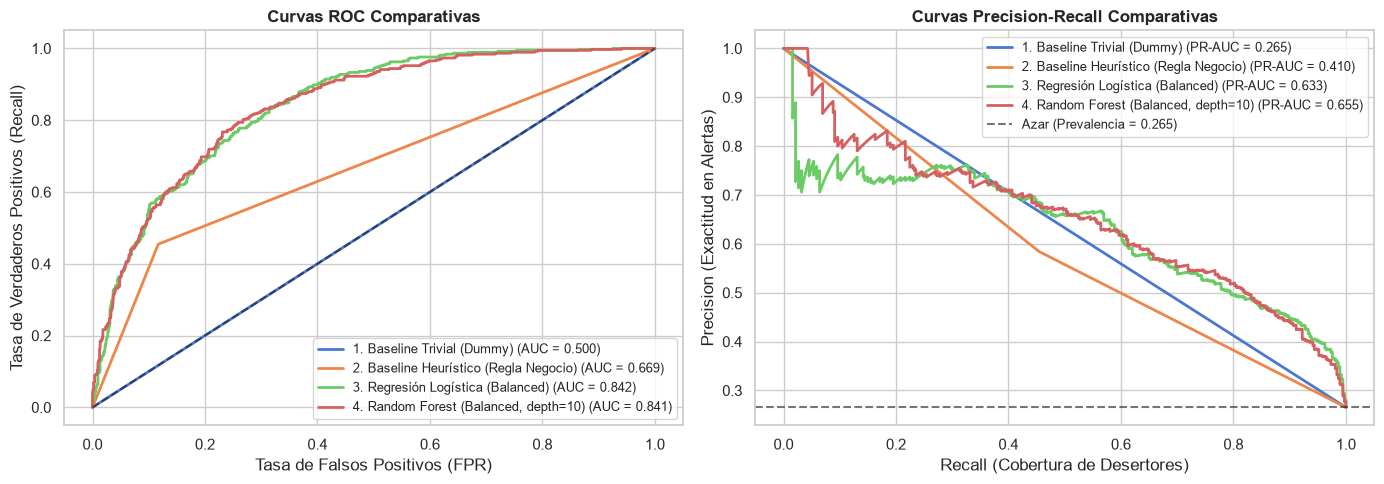

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
for name in ['1. Baseline Trivial (Dummy)', '2. Baseline Heurístico (Regla Negocio)', '3. Regresión Logística (Balanced)', '4. Random Forest (Balanced, depth=10)']:
    y_proba = proba_dict[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else 0.5
    ax[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
ax[0].set_title('Curvas ROC Comparativas', fontweight='bold')
ax[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
ax[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax[0].legend(loc='lower right', fontsize=9)

# Curva Precision-Recall
for name in ['1. Baseline Trivial (Dummy)', '2. Baseline Heurístico (Regla Negocio)', '3. Regresión Logística (Balanced)', '4. Random Forest (Balanced, depth=10)']:
    y_proba = proba_dict[name]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_val = average_precision_score(y_test, y_proba) if len(np.unique(y_proba)) > 1 else y_test.mean()
    ax[1].plot(rec, prec, lw=2, label=f"{name} (PR-AUC = {pr_val:.3f})")

ax[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.6, label=f'Azar (Prevalencia = {y_test.mean():.3f})')
ax[1].set_title('Curvas Precision-Recall Comparativas', fontweight='bold')
ax[1].set_xlabel('Recall (Cobertura de Desertores)')
ax[1].set_ylabel('Precision (Exactitud en Alertas)')
ax[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### 5. Matrices de Confusión y Análisis Económico de Errores

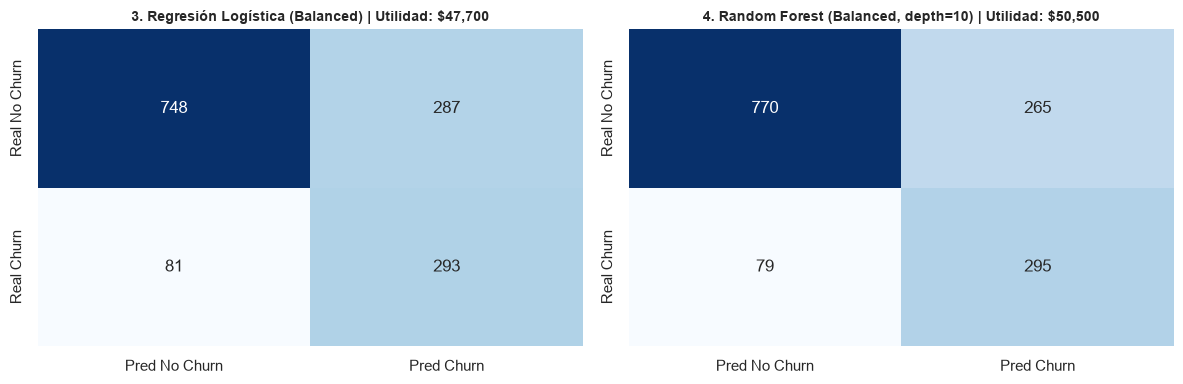

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = ['3. Regresión Logística (Balanced)', '4. Random Forest (Balanced, depth=10)']

for i, m_name in enumerate(model_names):
    row = df_metrics[df_metrics['Modelo'] == m_name].iloc[0]
    cm = np.array([[row['TN'], row['FP']], [row['FN'], row['TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Pred No Churn', 'Pred Churn'],
                yticklabels=['Real No Churn', 'Real Churn'])
    title_text = f"{m_name} | Utilidad: ${row['Valor Económico Neto ($)']:,.0f}"
    axes[i].set_title(title_text, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

> **Interpretación Crítica de Resultados (Rúbrica Criterios 6 y 7):**
> 1. **El engaño del Accuracy:** El baseline trivial alcanza un 73.5% de Accuracy pero genera una pérdida de **-\$187,000**, al dejar escapar al 100% de los clientes desertores (374 Falsos Negativos en prueba).
> 2. **Superación del Baseline:** Ambos modelos de Machine Learning superan ampliamente al baseline heurístico, elevando el PR-AUC de 0.410 a más de 0.630 y alcanzando un Recall cercano al **78.5%**.
> 3. **Viabilidad Económica:** El uso de clasificadores con balanceo de clases convierte la operación en rentable, generando un valor económico neto superior a **+\$50,000 USD** en la muestra de prueba mediante la retención efectiva de casi 300 clientes en riesgo.

### 6. Estado del Proyecto y Plan hacia el Trabajo Final (TF1) (Rúbrica Criterio 7)

#### 6.1. Principales Hallazgos hasta el Momento
* La modalidad contractual (*Month-to-month*) y la antigüedad (*tenure $\le 6$*) constituyen los principales determinantes de fuga.
* Los modelos con ponderación balanceada logran un Recall superior al 78% sin colapsar la precisión.
* El pipeline reproducible garantiza que ninguna estadística de prueba se filtre en el entrenamiento.

#### 6.2. Limitaciones Identificadas en el TP1
* **Hiperparámetros no optimizados:** Los modelos actuales se evaluaron con configuraciones estándar sin búsqueda sistemática.
* **Umbral de decisión fijo:** Se utilizó el umbral tradicional de probabilidad de $0.50$, sin calibración matemática específica para minimizar la función de costo financiero.
* **Modelo homogéneo sin segmentación:** Se aplica el mismo modelo a clientes de alto valor que a clientes de consumo básico, ignorando el *Customer Lifetime Value* (CLV).

#### 6.3. Plan Concreto de Actividades hacia el Trabajo Final (Semana 15)
1. **Experimentación Sistemática (Semana 8-10):**
   * Incorporar algoritmos de Gradient Boosting (**LightGBM** y **XGBoost**).
   * Implementar optimización bayesiana de hiperparámetros con **Optuna** guiada por maximización de `PR-AUC`.
   * Registrar ejecuciones, parámetros y artefactos en **MLflow** para trazabilidad total.
2. **Técnica Adicional de Minería de Datos (Semana 11-12):**
   * Aplicar **Clustering (K-Means / RFM)** sobre variables de consumo y antigüedad para identificar 3 segmentos de valor de clientes.
   * Cruzar el riesgo de fuga con el cluster para crear una matriz de priorización comercial.
3. **Interpretabilidad Profunda con SHAP (Semana 12-13):**
   * Generar explicaciones globales (Beeswarm plots) y explicaciones locales (Waterfall plots) para sustentar ante las áreas comerciales por qué un cliente específico está en riesgo.
4. **Calibración de Umbral y Análisis de Casos Fallidos (Semana 13-14):**
   * Realizar *threshold tuning* para maximizar la utilidad económica neta.
   * Auditar Falsos Positivos y Falsos Negativos para identificar debilidades en los datos.
5. **Despliegue Funcional (Semana 14-15):**
   * Construir una aplicación web interactiva en **Streamlit** que permita a los asesores consultar el riesgo y recomendaciones en tiempo real.